## GymVibe: гибридная контекстная рекомендательная система
- Система подбора музыки для тренировок, которая адаптируется под текущую интенсивность (аудио-архетипы) и персональный темп пользователя.
- Архитектура:
    Two-Stage Recommender System:
    1. Retrieval (L0): Двухбашенная нейросеть (Two-Tower/DSSM) на PyTorch для быстрого поиска кандидатов в векторном пространстве.
    2. Ranking (L1): Градиентный бустинг (CatBoost) с функцией потерь YetiRank для финального переранжирования с учетом контекста.

### Настройки и импорт

In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.manifold import TSNE
from sklearn.metrics import ndcg_score
from sklearn.preprocessing import StandardScaler
from catboost import CatBoostRanker, Pool
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set(style="whitegrid")

VIBE_LABELS = ['Boss Fight / Doom Slayer', 'Zen / Lo-Fi Recovery', 'Golden Era (Old School)', 
               'Pilates Girl', 'Pure Rage / Metalhead', 'Sigma Grindset', 'Пацанский Вайб']
FEATURE_COLS = ['bpm', 'gain', 'street_score', 'lyrics_word_count', 'power_index', 'word_density']

### 1. Feature Engineering & Preprocessing

- Акустические признаки
- Power Index: Соотношение темпа и громкости (энергетика трека).
- Street Score: Счетчик "уличных" маркеров в тексте.
- Word Density: Плотность текста относительно длительности.


In [2]:
class GymFeatureProcessor:
    def __init__(self):
        self.scaler = StandardScaler()

    def transform(self, df):
        df = df.copy()
        df['clean_lyrics'] = df['clean_lyrics'].fillna('').apply(lambda x: re.sub(r'\[.*?\]', '', str(x)).lower())
        df['street_score'] = df['clean_lyrics'].apply(lambda x: sum(1 for w in ['street', 'block', 'gang', 'money', 'hustle', 'choppa', 'glock'] if w in x))
        
        df['word_density'] = df['lyrics_word_count'] / (df['itunes_duration_ms'] / 1000 + 1)
        df['power_index'] = (df['bpm'] * (df['gain'].fillna(-10) + 25)) / 100
        
        df[FEATURE_COLS] = self.scaler.fit_transform(df[FEATURE_COLS].fillna(0))
        return df

### 2. Retrieval Layer (Two-Tower Neural Network)

In [3]:
class Tower(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, emb_dim)
        )
    def forward(self, x): return self.net(x)

class TwoTowerModel(nn.Module):
    def __init__(self, input_dim, emb_dim=64):
        super().__init__()
        self.user_tower = Tower(input_dim, emb_dim)
        self.item_tower = Tower(input_dim, emb_dim)
    def forward(self, u, i): return self.user_tower(u), self.item_tower(i)

### 3. Ranking Layer (CatBoost YetiRank)

 Берутся кандидаты, предложенные нейросетью и выполняется Pairwise ранжирование + алгоритм YetiRank.

In [9]:
class GymVibeRecSys:
    def __init__(self, songs_df):
        self.songs_df = songs_df
        self.processor = GymFeatureProcessor()
        self.ranker = CatBoostRanker(iterations=800, learning_rate=0.03, depth=6, 
                                     loss_function='YetiRankPairwise', verbose=False)
        self.retrieval_nn = None
        self.train_pool = None 
        
    def build_pipeline(self, interactions_df):
        self.songs_df = self.processor.transform(self.songs_df)
        
        merged = interactions_df.merge(self.songs_df[FEATURE_COLS + ['track_name']], on='track_name')
        u_f = torch.FloatTensor(merged[['user_pref_bpm']].values).repeat(1, len(FEATURE_COLS))
        i_f = torch.FloatTensor(merged[FEATURE_COLS].values)
        target = torch.where(torch.tensor(merged['like'].values.astype(float)) == 1, torch.tensor(1.0), torch.tensor(-1.0))
        
        self.retrieval_nn = TwoTowerModel(len(FEATURE_COLS))
        opt = optim.Adam(self.retrieval_nn.parameters(), lr=0.005)
        for _ in range(30):
            u_e, i_e = self.retrieval_nn(u_f, i_f)
            loss = nn.CosineEmbeddingLoss()(u_e, i_e, target)
            opt.zero_grad(); loss.backward(); opt.step()
        print(f"Retrieval Trained. Loss: {loss.item():.4f}")

        rank_df = interactions_df.merge(self.songs_df[FEATURE_COLS + ['track_name', 'genre_final']], on='track_name')
        rank_df = rank_df.sort_values('session_id')
        
        with torch.no_grad():
            u_f_rank = torch.FloatTensor(rank_df[['user_pref_bpm']].values).repeat(1, len(FEATURE_COLS))
            i_f_rank = torch.FloatTensor(rank_df[FEATURE_COLS].values)
            u_e, i_e = self.retrieval_nn(u_f_rank, i_f_rank)
            rank_df['nn_score'] = torch.cosine_similarity(u_e, i_e).numpy()
        
        X = rank_df[FEATURE_COLS + ['context', 'genre_final', 'user_pref_bpm', 'nn_score']]
        self.train_pool = Pool(data=X, label=rank_df['like'], group_id=rank_df['session_id'], cat_features=['context', 'genre_final'])
        self.ranker.fit(self.train_pool)
        print("Ranking Layer Trained.")

    def recommend(self, user_pref_bpm, context_vibe, n=5):
        self.retrieval_nn.eval()
        with torch.no_grad():
            u_input = torch.FloatTensor([[user_pref_bpm]*len(FEATURE_COLS)])
            u_emb = self.retrieval_nn.user_tower(u_input)
            i_inputs = torch.FloatTensor(self.songs_df[FEATURE_COLS].values)
            i_embs = self.retrieval_nn.item_tower(i_inputs)
            nn_retrieval_scores = torch.cosine_similarity(u_emb, i_embs).numpy()
        
        self.songs_df['nn_score'] = nn_retrieval_scores
        candidates = self.songs_df.sort_values('nn_score', ascending=False).head(50).copy()
        candidates['context'] = context_vibe
        candidates['user_pref_bpm'] = user_pref_bpm
        
        rank_feats = FEATURE_COLS + ['context', 'genre_final', 'user_pref_bpm', 'nn_score']
        candidates['final_score'] = self.ranker.predict(candidates[rank_feats])
        return candidates.sort_values('final_score', ascending=False).head(n)

#### Оценка модели (NDCG)

In [10]:
def get_ndcg(recsys, logs_df):
    all_ndcg = []
    test_sessions = logs_df['session_id'].unique()[:30]
    for sid in test_sessions:
        sess_data = logs_df[logs_df['session_id'] == sid]
        actual_liked = sess_data[sess_data['like'] == 1]['track_name'].values
        if len(actual_liked) == 0: continue
        context = sess_data['context'].iloc[0]
        bpm = sess_data['user_pref_bpm'].iloc[0]
        preds = recsys.recommend(bpm, context, n=20)
        y_true = np.array([[1 if t in actual_liked else 0 for t in preds['track_name']]])
        y_score = np.array([preds['final_score'].values])
        if y_true.sum() > 0:
            all_ndcg.append(ndcg_score(y_true, y_score, k=5))
    return np.mean(all_ndcg) if all_ndcg else 0

In [11]:
def generate_pro_logs(df_songs, n_users=200):
    data = []
    for user_id in range(n_users):
        user_pref_bpm = np.random.normal(0, 1)
        for sess_id in range(4):
            context = np.random.choice(VIBE_LABELS)
            vibe_pool = df_songs[df_songs['target'] == context].sample(min(10, 50))
            rand_pool = df_songs.sample(10)
            session_pool = pd.concat([vibe_pool, rand_pool])
            for _, song in session_pool.iterrows():
                prob = 0.05
                if song['target'] == context: prob += 0.45
                if abs(song['bpm'] - user_pref_bpm) < 0.5: prob += 0.4
                like = 1 if np.random.random() < prob else 0
                data.append({'user_id': user_id, 'session_id': f"{user_id}_{sess_id}", 
                             'track_name': song['track_name'], 'user_pref_bpm': user_pref_bpm, 
                             'context': context, 'like': like})
    return pd.DataFrame(data)

### 4. Запуск пайплайна

In [12]:
df_raw = pd.read_csv('featured_data_1.csv')
logs = generate_pro_logs(df_raw) 

system = GymVibeRecSys(df_raw)
system.build_pipeline(logs)

test_user = logs.iloc[25]
res = system.recommend(test_user['user_pref_bpm'], 'Boss Fight / Doom Slayer')
print("\n Персонализированный топ для тренировки:")
print(res[['artist_name', 'track_name', 'final_score']])

print(f"\nСредний NDCG@5 на тестовых сессиях: {get_ndcg(system, logs):.4f}")

Retrieval Trained. Loss: 0.3396
Ranking Layer Trained.

 Персонализированный топ для тренировки:
                 artist_name      track_name  final_score
428            Yuka Kitamura  Abyss Watchers     1.621210
637  M83 ft. Susanne Sundfør        Oblivion     1.582548
597               Скриптонит           Тоска     1.400368
523                Boy Pablo           Honey     1.247609
598                    Баста        Временно     1.238070

Средний NDCG@5 на тестовых сессиях: 0.2055


#### Важность признаков

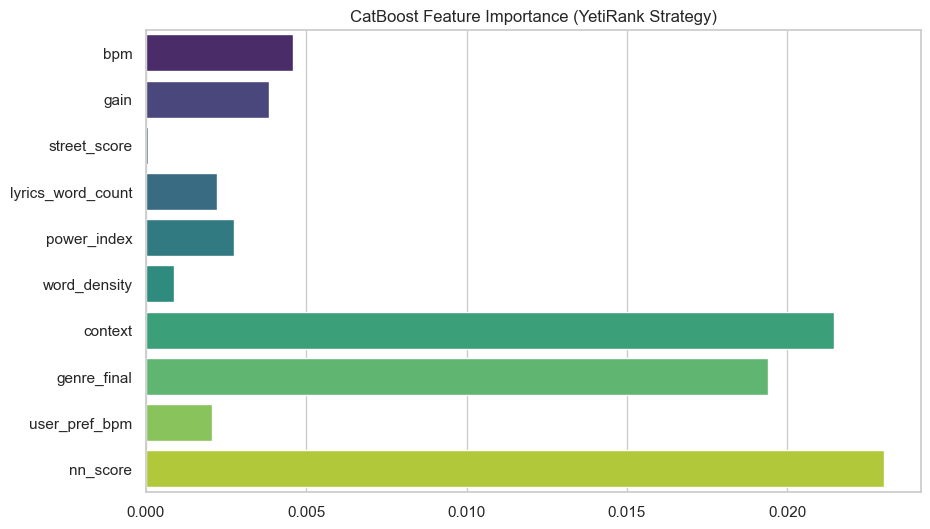

In [13]:
plt.figure(figsize=(10, 6))
importance = system.ranker.get_feature_importance(system.train_pool)
f_names = FEATURE_COLS + ['context', 'genre_final', 'user_pref_bpm', 'nn_score']
sns.barplot(x=importance, y=f_names, palette='viridis')
plt.title("CatBoost Feature Importance (YetiRank Strategy)")
plt.show()

#### t-SNE Визуализация

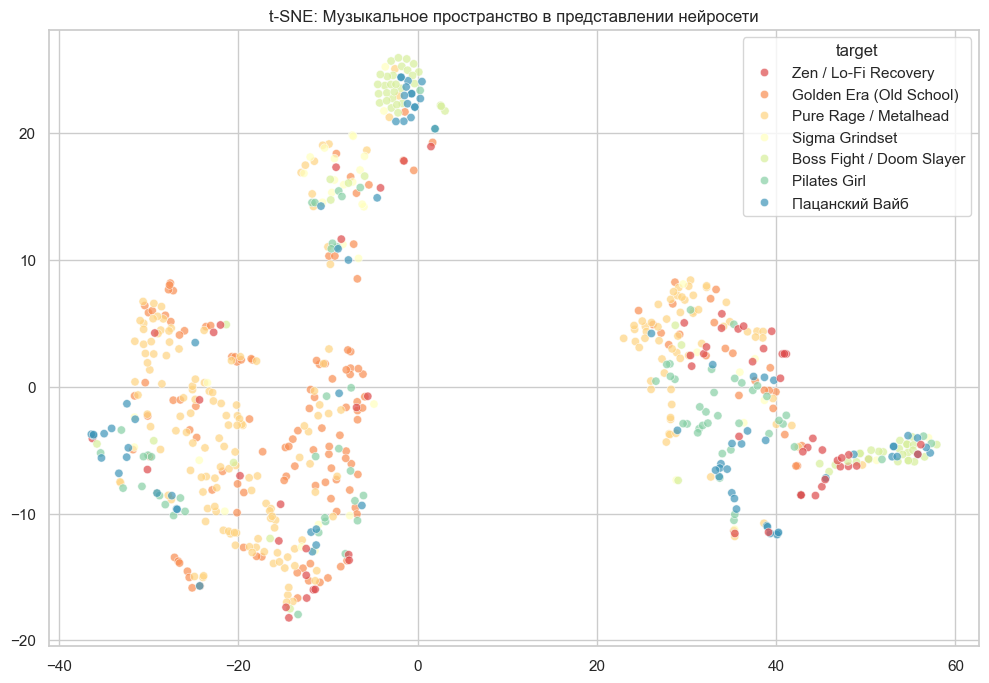

In [14]:
def plot_final_tsne(recsys):
    recsys.retrieval_nn.eval()
    with torch.no_grad():
        inputs = torch.FloatTensor(recsys.songs_df[FEATURE_COLS].values)
        embs = recsys.retrieval_nn.item_tower(inputs).numpy()
    reduced = TSNE(n_components=2, perplexity=30).fit_transform(embs)
    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=recsys.songs_df['target'], palette='Spectral', alpha=0.7)
    plt.title("t-SNE: Музыкальное пространство в представлении нейросети")
    plt.show()

plot_final_tsne(system)